We implement Cylindrical Algebraic Decomposition (CAD) in SQL to decide formulas
of Linear Real Arithmetic (LRA).

# 1.1 CAD Basics

We consider a concrete example to show our approach to CAD. Recall that in
general, CAD consists of a recursive projection phase that projects equations to
one dimension lower, until we reach dimension 1\. We follow this with a
recursive lifting phase, which starts at the projected equations of dimension 1
and lifts sample points to the highest dimension, one dimension at a time. The
result is a list of sample points for each sign-invariant cell of the CAD.

## 2D Example

Let's start with an easy 2-dimensional example.

Our implementation is motivated by neural network verification. A central
problem here is the ReLU function. Consider the following ReLU-inspired formula:

$$

f(x) = 
    \begin{cases}
        2x & \text{if } x > 0\\
        0 & \text{if } x \leq 0
    \end{cases}
$$

Now say we want to verify the following formula, where we add $F$ to our first
order logic vocabulary to represent the function evaluation:

$\exists x . F(x) > 5 \land x < 5$

To "compile" $F(x)$, we introduce a new variable $u$ representing the function
output:

$F(x) = u \land u > 5$

Then we "plug in" our ReLU-like function, making the entire formula:

$$
\exists x \exists u . 
((x < 0 \implies u = 0) \land (x \geq 0 \implies u = 2x)) 
\land (u > 5) 
\land (x < 5)
$$

Now to be more general, take $x_1$ to be $x$ and $x_2$ to be $u$. Our formula
contains the following constraints:

- $x_1 < 0$
- $x_1 \geq 0$
- $x_1 - 5 < 0$
- $x_2 = 0$
- $-2x_1 + x_2 = 0$
- $-5 + x_2 = 0$

These constraints form hyperplanes, which will be the input to our projection
phase. First, we project $x_2$. To do this, we take all hyperplanes of $x_2$'s
dimension:

- $x_2 = 0$
- $-2x_1 + x_2 = 0$
- $-5 + x_2 = 0$

Of these, we calculate the pairwise intersections by moving $x_2$ to the
right-hand side of each equation and equating them:

- $0 = -2x_1$ -> $x_1 = 0$
- $-5 = 0$ -> no solution
- $-2x_1 = -5$ -> $x_1 = 2.5$

Now we also add all hyperplanes that only contain $x_1$; the "vertical"
hyperplanes. This is $x_1 = 0$, which we already have, and
$x_1 = 5$ (from $x_1 - 5 < 0$).

Thus, our resulting points in dimension 1 are 0, 2.5, and 5. These will form our
intervals. For each interval we take a sample point representing that interval.
CAD guarantees that the entire cell (= interval) is sign-invariant, so every
point within a cell leads to the same eventual truth value of the LRA formula.

These are our resulting intervals and sample points:

- $(\infty, 0)$ with sample point -1
- $(0,0)$ with sample point 0
- $(0, 2.5)$ with sample point 1.25
- $(2.5, 2.5)$ with sample point 2.5
- $(2.5, 5)$ with sample point 3.75
- $(5, 5)$ with sample point 5
- $(5, +\infty)$ with sample point 6

Each cell in dimension 1 has a "stack above" of cells in dimension 2. These
cells are created by the hyperplanes that divide the area above the cell. In our
case, we simply consider every 2D hyperplane of the 2D projection step to
delineate the stack above.

Thus, our lifting phase from 1D to 2D is simply evaluating each 1D sample point
against the 2D hyperplane. For example:

- We evaluate sample point -1 to:
  - $-2x_1 + x_2 = 0 \implies x_2 = 2 \cdot -1 = -2$
  - $-5 + x_2 = 0 \implies x_2 = 5$
- We evaluate sample point 0 to:
  - $-2x_1 + x_2 = 0 \implies x_2 = 2 \cdot 0 = 0$
  - $-5 + x_2 = 0 \implies x_2 = 5$
- ... and so on.

Let's consider sample point 3.75 in particular. This yields $x_1=3.75$ and
$x_2=7.5$ (by hyperplane $-2x_1 + x_2 = 0$). Now consider our original LRA
formula:

$$
\exists x_1 \exists x_2 . 
((x_1 < 0 \implies x_2 = 0) \land (x_1 \geq 0 \implies x_2 = 2x_1)) 
\land (x_2 > 5) 
\land (x_1 < 5)
$$

Plugging in our sample point, we get:

$$
((3.75 < 0 \implies 7.5 = 0) \land (3.75 \geq 0 \implies 7.5 = 2\cdot 3.75)) 
\land (7.5 > 5) 
\land (3.75 < 5)
$$

We see this formula is true! We have eliminated the existential quantifiers and
deduced that there is a satisfying assignment for the LRA formula (namely
$x_1=3.75$ and $x_2=7.5$).


## 3D Example

We can go one dimension higher and show our process again, when we actually have
some more projecting and lifting to do. 

Take $f(x,y) = max(0, x + y)$ and LRA formula
$\exists x \exists y . F(x,y) > 2 \land x < 2 \land y < 2$

Following our "compilation" from the previous section, the full formula becomes:

$$
\exists x,y,z .
((x + y < 0 \implies z=0) \lor (x + y \geq 0 \implies z = x + y))
\land (z > 2) \land (x < 2) \land (y < 2)
$$

We work with $x,y,z$ directly this time, as opposed to $x_i$. All constraints
are now:

1. $x + y$
2. $z$
3. $x + y - z$
4. $z - 2$
5. $x - 2$
6. $y - 2$

**Step 1: project z**. All hyperplanes containing $z$ are 2, 3, and 4. We calculate
the pairwise intersections:

- 2x3: $x + y = 0$
- 2x3: no solution
- 3x4: $x + y - 2 = 0$

Then we add the vertical hyperplanes again:

1. $x + y$ (from 2x3, but also from hyperplane 1)
2. $x + y - 2$
3. $x - 2$
4. $y - 2$

**Step 2: project y**. All hyperplanes containing $y$ are 1, 2, and 4.

- 1x2: no solution
- 1x4: $x + 2= 0$
- 2x4: $x = 0$

And we add the single vertical hyperplane $x = 2$ again.

**Step 3: lifting**. We have the following intervals in dimension 1:

- $(-\infty, -2)$
- $(-2, -2)$
- $(-2, 0)$
- $(0, 0)$
- $(0, 2)$
- $(2, 2)$
- $(2, +\infty)$

We have to lift all of these to dimension 2 and then all those again to
dimension 3. We show this for a few points.

- $(-\infty, -2)$
  - Take sample point $x=-4$
  - Then (hyperplanes step 1): $y=2$, $y=4$, $y=6$. These form intervals again,
    of which we take a sample point.
    - $(-4, 1)$ 
      - Hyperplane 2: $z=0$ -> UNSAT (remember, $x$ and $y$ have to be less than
        2, and $z$ greater than 2).
      - Hyperplane 3: $z=-3$ -> UNSAT 
      - Hyperplane 4: $z=2$ -> UNSAT
    - $(-4, 2)$ -> UNSAT
    - $(-4, 3)$ -> UNSAT
    - $(-4, 4)$ -> UNSAT
    - $(-4, 5)$ -> UNSAT
    - $(-4, 6)$ -> UNSAT
    - $(-4, 7)$ -> UNSAT
- $(-2, -2)$
  - Take sample point $x=-2$
  - Then (hyperplanes step 1): $y=2$, $y=4$
    - $(-2, 1)$ -> UNSAT
    - Rest also UNSAT, because $y<2$ is always false.
- etc. etc
- $(0, 2)$
  - Take sample point $x=1$
  - Then (hyperplanes step 1): $y=-1$, $y=1$, $y=2$.
    - $(1,-2)$ -> UNSAT
    - $(1, -1)$ -> UNSAT
    - $(1, 0)$ -> UNSAT
    - $(1, 1)$ -> UNSAT
    - $(1, 1.5)$ -> **SAT**
    - $(1, 2)$ -> UNSAT
    - $(1, 3)$ -> UNSAT

We find a satisfying assignment for $x=1$, $y=1.5$ and $z=2.5$. Our quantifier
elimination process thus resolves to true! Keep in mind that if we had a
universal quantifier, the end result would be false (because not every cell
evaluates to true).

## Translation to SQL

We will now translate our second example to SQL. To warm up, we will do each
project and lift step explicitly. That is, we assume the number of dimensions is
known beforehand so we can write (or compile) our SQL query. In the next section
we will create a recursive query that can handle any number of dimensions.

First, let's create our database schema. We will have a table
`LinearConstraint(id, description)` that gives each constraint a unique ID. The
table `Coefficient(constraint_id, dimension, value)` holds the values of the
$a_0, a_1, \ldots$ coefficients. Note that we use one row per coefficient.

In [1]:
import duckdb as db

DBNAME = "dbs/cad_basic.db"

def create_db_with_constraints(con, constraints):
    con.sql("DROP TABLE IF EXISTS LinearConstraint")
    con.sql("""
        CREATE TABLE LinearConstraint(
            id INTEGER PRIMARY KEY,
            description VARCHAR NOT NULL
        )
    """)

    con.sql("DROP TABLE IF EXISTS Coefficient")
    con.sql("""
        CREATE TABLE Coefficient(
            constraint_id VARCHAR NOT NULL, -- VARCHAR omdat we dingen zoals 1x2 willen doen
            dimension INTEGER NOT NULL,
            value DOUBLE NOT NULL,
            PRIMARY KEY (constraint_id, dimension)
        )
    """)


    for constraint_id, coeffs in enumerate(constraints):
        con.execute("""
            INSERT INTO LinearConstraint(id, description)
            VALUES ($id, $description)
        """, {'id': constraint_id, 'description': coeffs[0]})

        for dimension, coeff_value in enumerate(coeffs[1:]):
            con.execute("""
                INSERT INTO Coefficient(constraint_id, dimension, value)
                VALUES ($constraint_id, $dimension, $value)
            """, {'constraint_id': constraint_id, 'dimension': dimension, 'value': coeff_value})

constraints = [
    ["x+y", 0, 1, 1],
    ["z", 0, 0, 0, 1],
    ["x+y-z", 0, 1, 1, -1],
    ["z-2", -2, 0, 0, 1],
    ["x-2", -2, 1],
    ["y-2", -2, 0, 1]
]

with db.connect(DBNAME) as con:
    create_db_with_constraints(con, constraints)

The non-recursive query lives in
[`queries/basic/nonrecursive.sql`](./queries/basic/nonrecursive.sql). This is a
lengthy query because of our decision to have a separate row for each
coefficient, and of course because of repeated work for each dimension. We
highlight some aspects of the query here.

Intersections of constraints are just a self-join:

```sql
WITH ...
zprojection_intersect_coeffs AS (
    SELECT
        -- We construct an artifical ID for traceability.
        (nc1.constraint_id || 'x' || nc2.constraint_id) AS constraint_id,
        nc1.dimension,
        nc2.value - nc1.value AS value
    FROM zprojection_normalized_constraints nc1
    JOIN zprojection_normalized_constraints nc2
        ON nc1.constraint_id <> nc2.constraint_id
        AND nc1.constraint_id < nc2.constraint_id -- Unique pairs (i.e. only 1x3, not also 3x1)
        AND nc1.dimension = nc2.dimension
)
```

When we are done projecting, intervals are a `UNION`:

```sql
x_intervals AS (
    SELECT
        x_value AS interval_start,
        x_value AS interval_end
    FROM x_values

    UNION

    SELECT
        a.x_value AS interval_start,
        MIN(b.x_value) AS interval_end
    FROM x_values a
    JOIN x_values b ON b.x_value > a.x_value
    GROUP BY a.x_value

    UNION

    -- Artifical lower and upper interval.
    SELECT '-infinity'::DOUBLE, MIN(x_value) FROM x_values
    UNION
    SELECT MAX(x_value), '+infinity'::DOUBLE FROM x_values

    ORDER BY interval_start, interval_end
),
```

And taking sample points is simply taking the middle value, with special
handling for infinities.

```sql
sample_points AS (
    SELECT
        CASE
            WHEN ISINF(interval_start) THEN interval_end - 1.0
            WHEN ISINF(interval_end) THEN interval_start + 1.0
            ELSE (interval_start + interval_end) / 2.0
        END AS sample_point
    FROM x_intervals
),
```

Lifting these points up involves evaluating the constraints of the related
projection step.

```sql
x_lift_y_eval AS (
    SELECT
        i.input_id,
        SUM(i.value * xl.value) AS y_value
    FROM x_lift_normalized xl
    JOIN sample_input_values i
        ON xl.dimension = i.dimension
    GROUP BY i.input_id, xl.constraint_id
),
```

The result is a list of constraints, for which we can check if our desired
(in)equalities hold.

```sql
sat_input_ids AS (
    SELECT input_id FROM results WHERE description = 'z-2' AND result > 0
    -- INTERSECT for AND, UNION for OR.
    INTERSECT
    SELECT input_id FROM results WHERE description = 'x-2' AND result < 0
    INTERSECT
    SELECT input_id FROM results WHERE description = 'y-2' AND result < 0
),
solutions AS (
    SELECT * FROM xyz_input_values
    NATURAL JOIN sat_input_ids
    WHERE dimension > 0
    ORDER BY dimension
)
```

Let's evaluate this query to view the output.

In [2]:
with open('queries/basic/nonrecursive.sql') as file:
    query = file.read()

with db.connect(DBNAME) as con:
    display(con.sql(query))

┌──────────┬───────────┬────────┐
│ input_id │ dimension │ value  │
│ varchar  │   int32   │ double │
├──────────┼───────────┼────────┤
│ x5y5z3   │         1 │    1.0 │
│ x5y5z3   │         2 │    1.5 │
│ x5y5z3   │         3 │    2.5 │
└──────────┴───────────┴────────┘

The result is exactly the point we found in our manual calculations.

## Recursive Query

Ideally we want to evaluate formulas of arbitrary dimensions. For this, we
adapted our hardcoded query to a recursive Common Table Expression (CTE).

The full query can be found in
[queries/basic/recursive.sql](./queries/basic/recursive.sql). The
logic remains the same, but we have a recursive expression for the project phase
(`recursive_projections`) and the lifting phase (`recursive_lifts`).

In [3]:
with open('queries/basic/recursive.sql') as file:
    query = file.read()

with db.connect(DBNAME) as con:
    display(con.sql(query))

┌──────────┬───────────┬────────┐
│ input_id │ dimension │ value  │
│ varchar  │   int32   │ double │
├──────────┼───────────┼────────┤
│ 5.4.2    │         1 │    1.0 │
│ 5.4.2    │         2 │    1.5 │
│ 5.4.2    │         3 │    2.5 │
└──────────┴───────────┴────────┘

The result is again the same, as expected!

## Higher Dimensions

Let's check an example of a dimension higher. We use a similar query as before.
Take $f(x,y, z) = max(0, x + y - z)$ and FO query:

$\exists x,y,z . F(x,y,z) > 2 \land x < 4 \land y < 4 \land z > 2$

Note that in our code we use a new query file. This because the actual
SAT-checking is still a manual translation to SQL; the CAD logic remains
identical.

In [4]:
constraints = [
    ["x+y-z", 0, 1, 1, -1],
    ["u", 0, 0, 0, 0, 1],
    ["x+y-z-u", 0, 1, 1, -1, -1],
    ["u-2", -2, 0, 0, 0, 1],
    ["x-4", -4, 1],
    ["y-4", -4, 0, 1],
    ["z-2", -2, 0, 0, 1]
]

with db.connect(DBNAME) as con:
    create_db_with_constraints(con, constraints)

    with open('queries/basic/example_4d.sql') as file:
        query = file.read()

    display(con.sql(query))

┌──────────┬───────────┬────────┐
│ input_id │ dimension │ value  │
│ varchar  │   int32   │ double │
├──────────┼───────────┼────────┤
│ 5.6.2.2  │         1 │    1.0 │
│ 5.6.2.2  │         2 │    3.5 │
│ 5.6.2.2  │         3 │   2.25 │
│ 5.6.2.2  │         4 │   2.25 │
│ 6.6.2.2  │         1 │    2.0 │
│ 6.6.2.2  │         2 │    2.5 │
│ 6.6.2.2  │         3 │   2.25 │
│ 6.6.2.2  │         4 │   2.25 │
│ 7.6.2.2  │         1 │    3.0 │
│ 7.6.2.2  │         2 │    1.5 │
│ 7.6.2.2  │         3 │   2.25 │
│ 7.6.2.2  │         4 │   2.25 │
└──────────┴───────────┴────────┘
  12 rows             3 columns

We see that this formula has more sample points satisfying the quantifier-free
formula.

## Performance

CAD is famously doubly exponential. Let's check how our SQL-based approach
scales with the number of dimensions.

We first need some code to create scenarios of a given dimension. For this, we
adapt our well-known example to arbitrary dimensions.

In [5]:
def generate_scenario_with_dimensions(con, dimensions):
    """
    Generalizes the formula:

    ∃x1,...,xk . (F(x1, ..., xk)) > k ∧ (x1 < k) ∧ ... ∧ (xk < k)

    Where F() is the ReLU of the summation, and k = dimensions - 1 (because the
    result of F() is given a new variable and thus a new dimension).
    """
    k = dimensions
    summation = ["+".join([f"x{i}" for i in range(1, dimensions + 1)]), 0] + [1 for _ in range(1, dimensions + 1)]
    out = ["u"] + [0 for _ in range(0, dimensions + 1)] + [1]
    relu = ["+".join([f"x{i}" for i in range(1, dimensions + 1)]) + "-u"] + [0] + [1 for _ in range(0, dimensions)] + [-1]

    lt_constraints = [[f"u-{k}", -k] + [0 for _ in range(0, dimensions)] + [1]]
    for i in range(1, dimensions + 1):
        lt_constraints.append([f"x{i}-{k}", -k] + [0 for _ in range(0, i-1)] + [1])

    constraints = [
        summation,
        out,
        relu
    ] + lt_constraints

    create_db_with_constraints(con, constraints)

def generate_query_with_dimensions(dimensions):
    k = dimensions

    with open('queries/basic/recursive_template.sql') as file:
        query_template = file.read()

    fol_parts = [f"SELECT input_id FROM results WHERE description = 'u-{k}' AND result > 0"]
    for i in range(1, dimensions + 1):
        fol_parts.append(f"SELECT input_id FROM results WHERE description = 'x{i}-{k}' AND result < 0")

    fol_part = " INTERSECT ".join(fol_parts)

    return query_template.format(sat_input_ids=fol_part)

We use a custom benchmarking tool that runs a query 5 times and takes the
average. Tests are run on a low-spec machine (4 cores, 8GB RAM). Note that if
you run these notebooks yourself, this might take a long time.

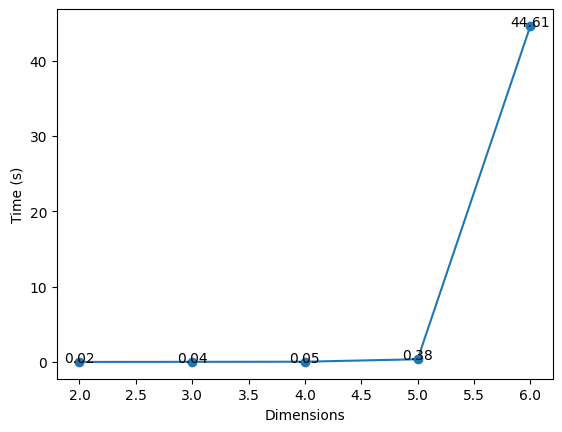

In [6]:
import util.perftest as perftest

with db.connect(DBNAME) as con:
    class BasicPerfTest(perftest.PerfTest):
        def name(self):
            return "basic_recursive"

        def setup_run(self, dimensions):
            # Note that we do `dimension - 1`, because our generator function is
            # named a bit unfortunate. `dimensions` are the number of arguments
            # to the function F we are testing, so including an output variable
            # we have an extra dimension.
            generate_scenario_with_dimensions(con, dimensions - 1)

        def run(self, dimensions):
            query = generate_query_with_dimensions(dimensions - 1)
            results = con.execute(query)

        def x_labels(self):
            return [3, 4, 5, 6]

    cad_perftest = perftest.measure_performance(BasicPerfTest())
    perftest.plot_df(cad_perftest, "Dimensions")

We see some very pessimistic scaling here. But, this approach is a first step.
In later notebooks, we will explore some optimizations and things look better
--- though we can't escape the exponential scaling.